In [1]:
import numpy as np
from matplotlib import pyplot as plt
from astropy import units as u
from astropy import constants as c
from scipy.integrate import quad, dblquad
from scipy.interpolate import CubicSpline
from tqdm import tqdm

In [2]:
# Physical constants

e_charge = 1.602e-19  # C
mu_air = 1.00000037*c.mu0.value
muon_mass = (105.65837 * u.MeV/c.c**2).to(u.kg).value  # kg
muon_lifetime = 2.19698e-6  # s

blue_UV = 380e-9  # m
UVB_UVC = 280e-9  # m
# UV_limit = 250e-9  # m

P_std = 101325  # Pa
T_15C = 288.15  # K

top_atmos_height = 112.8e3  # m
atmos_height = 11e3  # m  # relevant height

dry_adiab_lapse_rate = 9.76e-3  # K / m
molar_mass_dry_air = 0.02896968  # kg/mol

In [3]:
# VERITAS constants

PMT_min = 185e-9  # m
PMT_max = 650e-9  # m
constant_efficiency_factor = 0.88 * 0.97

D = 12  # m

veritas_alt = 1268  # m

In [4]:
measurements_dir = 'telescope_efficiency/'
qe_file = measurements_dir + 'quantum_efficiency.txt'
ref_T1_file = measurements_dir + 'reflectivity_T1.txt'
ref_T2_file = measurements_dir + 'reflectivity_T2.txt'
ref_T3_file = measurements_dir + 'reflectivity_T3.txt'
ref_T4_file = measurements_dir + 'reflectivity_T4.txt'

In [5]:
wvl_qe, qe = np.loadtxt(qe_file, skiprows=1, unpack=True)

In [6]:
wvl_ref_T1, ref_T1 = np.loadtxt(ref_T1_file, skiprows=1, unpack=True)
wvl_ref_T2, ref_T2 = np.loadtxt(ref_T2_file, skiprows=1, unpack=True)
wvl_ref_T3, ref_T3 = np.loadtxt(ref_T3_file, skiprows=1, unpack=True)
wvl_ref_T4, ref_T4 = np.loadtxt(ref_T4_file, skiprows=1, unpack=True)

In [7]:
qe_fct = CubicSpline(wvl_qe * 1e-9, qe)

ref_T1_fct = CubicSpline(wvl_ref_T1 * 1e-9, ref_T1)
ref_T2_fct = CubicSpline(wvl_ref_T2 * 1e-9, ref_T2)
ref_T3_fct = CubicSpline(wvl_ref_T3 * 1e-9, ref_T3)
ref_T4_fct = CubicSpline(wvl_ref_T4 * 1e-9, ref_T4)

ref_avg = np.mean((ref_T1, ref_T2, ref_T3, ref_T4), axis=0)
ref_fct = CubicSpline(wvl_ref_T1 * 1e-9, ref_avg)

In [8]:
wvl_range = np.linspace(UVB_UVC, PMT_max, 10000)

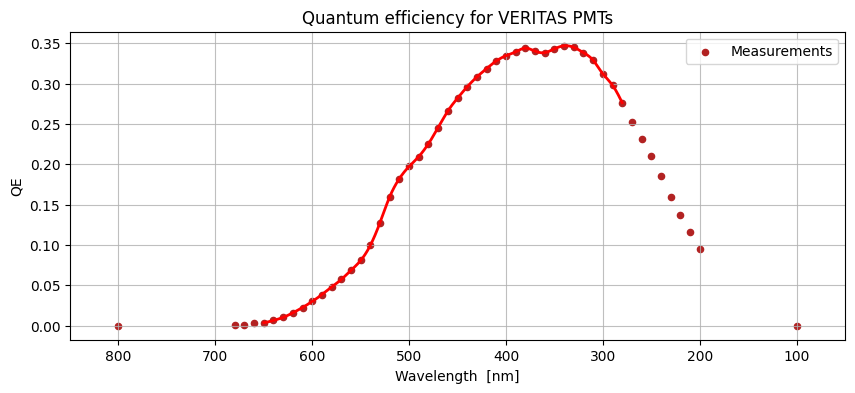

In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(wvl_range, qe_fct(wvl_range), c='red', lw=2)
plt.scatter(wvl_qe * 1e-9, qe, color='firebrick', s=20, label='Measurements')

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]')
plt.ylabel('QE')
plt.title('Quantum efficiency for VERITAS PMTs')

ticks = ax.xaxis.axes.get_xticks()
ticks_nm = [str(int(tick * 1e9)) for tick in ticks]
plt.xticks(ticks=ticks, labels=ticks_nm)

# plt.xlim(PMT_max, UVB_UVC)
plt.xlim(850e-9, 50e-9)

plt.legend()
plt.show()

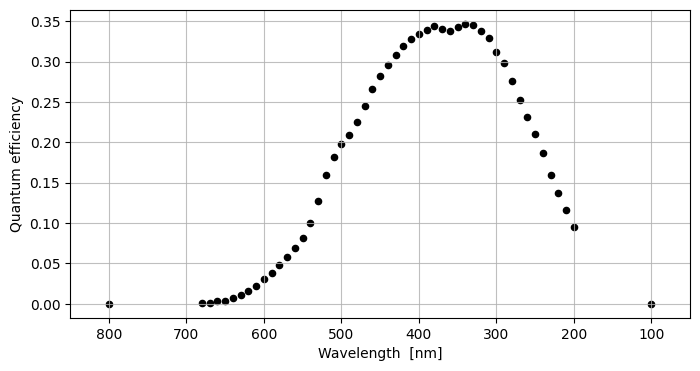

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

# plt.plot(wvl_range, qe_fct(wvl_range), c='red', lw=2)
plt.scatter(wvl_qe * 1e-9, qe, color='black', s=20)

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]')
plt.ylabel('Quantum efficiency')

ticks = ax.xaxis.axes.get_xticks()
ticks_nm = [str(int(tick * 1e9)) for tick in ticks]
plt.xticks(ticks=ticks, labels=ticks_nm)

# plt.xlim(PMT_max, UVB_UVC)
plt.xlim(850e-9, 50e-9)

plt.show()

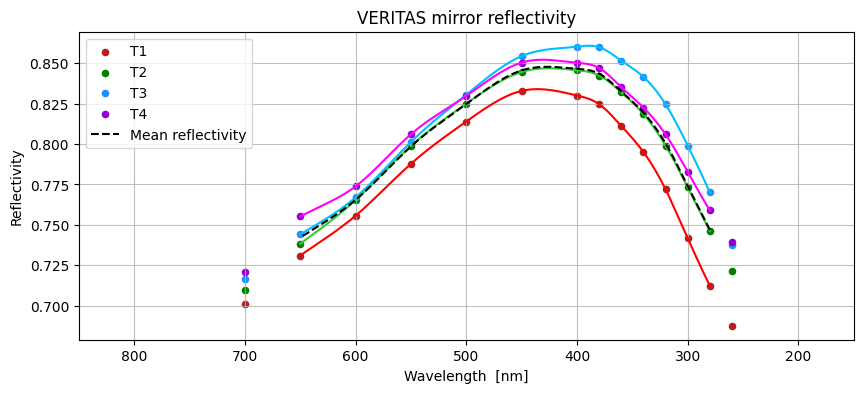

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(wvl_range, ref_T1_fct(wvl_range), c='red', lw=1.5)
plt.scatter(wvl_ref_T1 * 1e-9, ref_T1, color='firebrick', s=20, label='T1')

plt.plot(wvl_range, ref_T2_fct(wvl_range), c='limegreen', lw=1.5)
plt.scatter(wvl_ref_T2 * 1e-9, ref_T2, color='green', s=20, label='T2')

plt.plot(wvl_range, ref_T3_fct(wvl_range), c='deepskyblue', lw=1.5)
plt.scatter(wvl_ref_T3 * 1e-9, ref_T3, color='dodgerblue', s=20, label='T3')

plt.plot(wvl_range, ref_T4_fct(wvl_range), c='fuchsia', lw=1.5)
plt.scatter(wvl_ref_T4 * 1e-9, ref_T4, color='darkviolet', s=20, label='T4')

plt.plot(wvl_range, ref_fct(wvl_range), c='black', lw=1.5, ls='--', label='Mean reflectivity')

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]')
plt.ylabel('Reflectivity')
plt.title('VERITAS mirror reflectivity')

ticks = ax.xaxis.axes.get_xticks()
ticks_nm = [str(int(tick * 1e9)) for tick in ticks]
plt.xticks(ticks=ticks, labels=ticks_nm)

# plt.xlim(PMT_max, UVB_UVC)
plt.xlim(850e-9, 150e-9)

plt.legend()
plt.show()

In [12]:
wvl_range2 = np.linspace(wvl_ref_T1[0], wvl_ref_T1[-1], 10000)

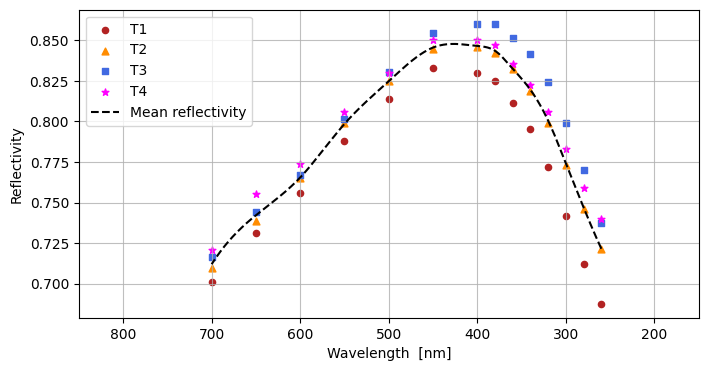

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))

plt.scatter(wvl_ref_T1 * 1e-9, ref_T1, color='firebrick', marker='o', s=20, label='T1')

plt.scatter(wvl_ref_T2 * 1e-9, ref_T2, color='darkorange', marker='^', s=24, label='T2')

plt.scatter(wvl_ref_T3 * 1e-9, ref_T3, color='royalblue', marker='s', s=22, label='T3')

plt.scatter(wvl_ref_T4 * 1e-9, ref_T4, color='fuchsia', marker='*', s=26, label='T4')

plt.plot(wvl_range2  * 1e-9, ref_fct(wvl_range2 * 1e-9), c='black', lw=1.5, ls='--', label='Mean reflectivity')

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]')
plt.ylabel('Reflectivity')

ticks = ax.xaxis.axes.get_xticks()
ticks_nm = [str(int(tick * 1e9)) for tick in ticks]
plt.xticks(ticks=ticks, labels=ticks_nm)

# plt.xlim(PMT_max, UVB_UVC)
plt.xlim(850e-9, 150e-9)

plt.legend()
plt.show()

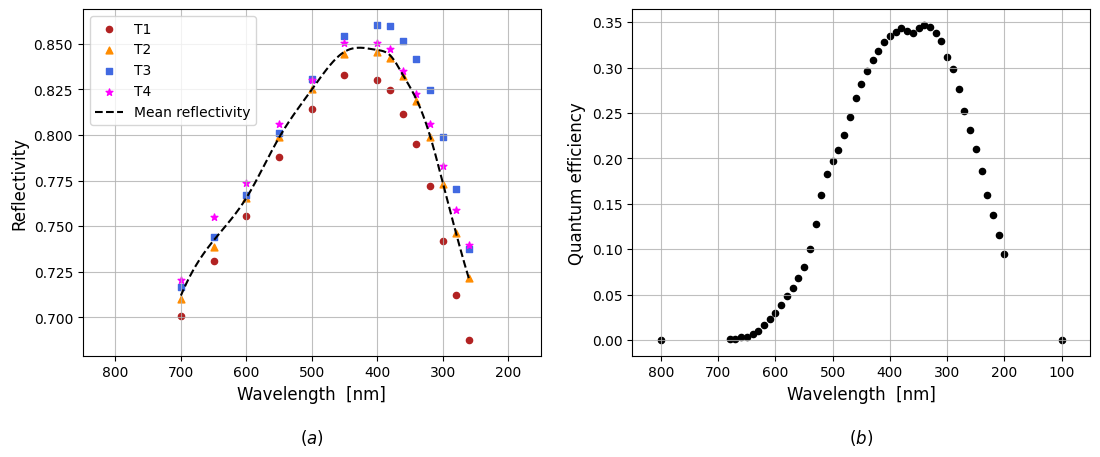

In [59]:
plt.figure(figsize=(13, 4.5))

plt.subplot(1, 2, 2)
plt.scatter(wvl_qe, qe, color='black', s=20)

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]\n\n' + r'($b$)', fontsize=12)
plt.ylabel('Quantum efficiency', fontsize=12)

plt.xlim(850, 50)

plt.subplot(1, 2, 1)
plt.scatter(wvl_ref_T1, ref_T1, color='firebrick', marker='o', s=20, label='T1')
plt.scatter(wvl_ref_T2, ref_T2, color='darkorange', marker='^', s=24, label='T2')
plt.scatter(wvl_ref_T3, ref_T3, color='royalblue', marker='s', s=22, label='T3')
plt.scatter(wvl_ref_T4, ref_T4, color='fuchsia', marker='*', s=26, label='T4')
plt.plot(wvl_range2, ref_fct(wvl_range2 * 1e-9), c='black', lw=1.5, ls='--', label='Mean reflectivity')

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]\n\n' + r'($a$)', fontsize=12)
plt.ylabel('Reflectivity', fontsize=12)

plt.xlim(850, 150)
plt.legend()

plt.show()

In [14]:
optimal_wvl_index = np.argmax(qe_fct(wvl_range) * ref_fct(wvl_range))
optimal_wvl = wvl_range[optimal_wvl_index]
print('Optimal detection wavelength: {} nm'.format(int(optimal_wvl * 1e9)))

Optimal detection wavelength: 380 nm


In [15]:
def get_pressure(alt):

    exponent = (c.g0.value * molar_mass_dry_air) / (c.R.value * dry_adiab_lapse_rate)
    base = 1 - (dry_adiab_lapse_rate * alt / T_15C)

    return P_std * base ** exponent

In [16]:
def get_temp(alt):
    return T_15C - (dry_adiab_lapse_rate * alt)

In [17]:
# This is to provide some weak dependence of n on lambda.
# This has a modest but appreciable impact in the Frank-Tamm equation due to the factor (1 - 1 / (beta * n))**2)
# Still regard lambda as being photon wavelength in vacuum; lambda = c / nu

def n_air(lam, alt=veritas_alt):

    # Empirically determined constants
    A = 2.73e-4 
    B = 1.23e-18  # m^2
    C = 3.56e-32  # m^4
    
    # Scale height of the atmosphere
    h_0 = 8.4e3  # m

    epsilon_0 = A + B/lam**2 + C/lam**4
    epsilon = epsilon_0 * np.exp(-alt / h_0)
    
    return 1 + epsilon

In [18]:
lams = np.linspace(UVB_UVC, PMT_max, 10000)
altitudes = np.linspace(0, atmos_height, 10000)
more_altitudes = np.linspace(0, top_atmos_height, 100000)

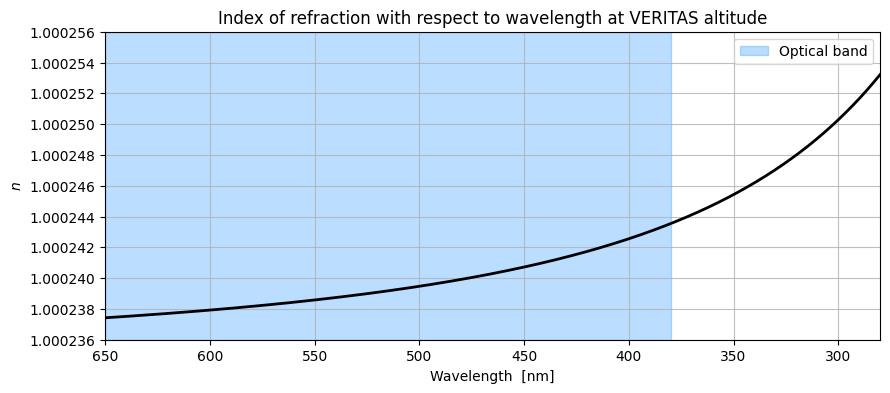

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))

plt.plot(lams, n_air(lams), c='black', lw=2)
plt.axvspan(blue_UV, PMT_max, color='dodgerblue', alpha=0.3, label='Optical band')

plt.grid(alpha=0.8)
plt.xlabel('Wavelength  [nm]')
plt.ylabel(r'$n$')
plt.title('Index of refraction with respect to wavelength at VERITAS altitude')

xticks = ax.xaxis.axes.get_xticks()
xticks_nm = [int(round(tick * 1e9)) for tick in xticks]
plt.xticks(ticks=xticks, labels=xticks_nm)

yticks = ax.yaxis.axes.get_yticks()
yticks_str = [f'%.6f' % tick for tick in yticks]
plt.yticks(ticks=yticks, labels=yticks_str)

# plt.xlim(PMT_min, PMT_max)
plt.xlim(PMT_max, UVB_UVC)

plt.legend()
plt.show()

In [20]:
P_vts = get_pressure(veritas_alt)
T_vts = get_temp(veritas_alt)

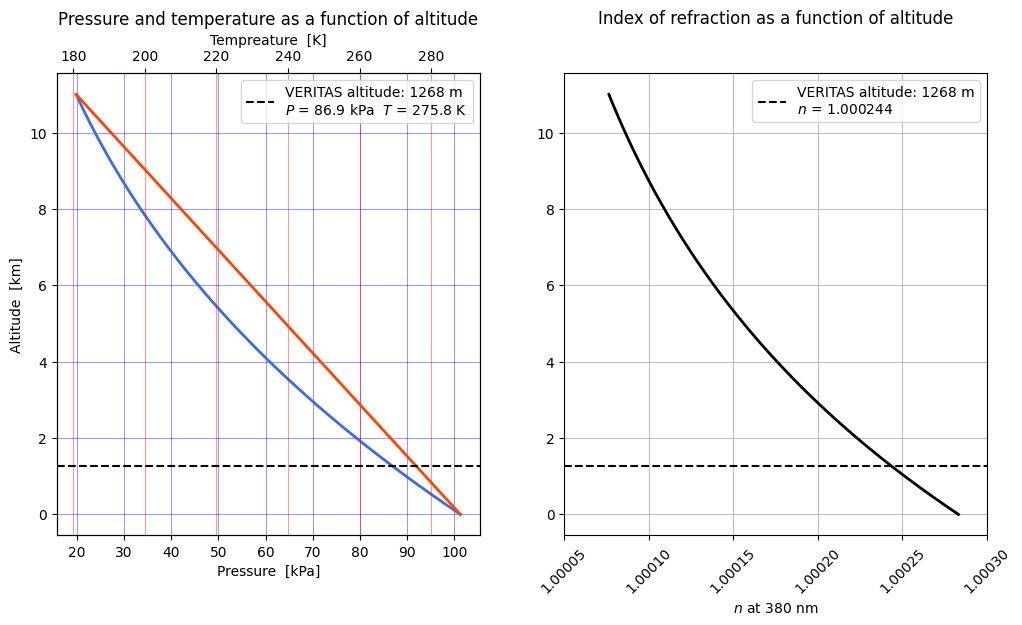

In [21]:
fig = plt.figure(figsize=(12, 6))

ax1 = fig.add_subplot(121)
ax2 = ax1.twiny()

ax1.plot(get_pressure(altitudes) / 1e3, altitudes / 1e3, c='royalblue', lw=2)
ax2.plot(get_temp(altitudes), altitudes / 1e3, c='orangered', lw=2)

ax2.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m\n$P$ = %.1f kPa\t$T$ = %.1f K' % (veritas_alt, P_vts / 1e3, T_vts))
ax2.legend()

ax1.grid(alpha=0.4, color='blue')
ax2.grid(alpha=0.4, color='red')

ax1.set_title('Pressure and temperature as a function of altitude')
ax1.set_ylabel('Altitude  [km]')
ax1.set_xlabel('Pressure  [kPa]')
ax2.set_xlabel('Tempreature  [K]')

ax3 = fig.add_subplot(122)

ax3.plot(n_air(optimal_wvl, altitudes), altitudes / 1e3, c='black', lw=2)
ax3.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m\n$n$ = %.6f' % (veritas_alt,
                                                           n_air(optimal_wvl, veritas_alt)))

ax3.legend()
ax3.grid(alpha=0.8)
ax3.set_title('Index of refraction as a function of altitude\n\n')
ax3.set_xlabel(r'$n$ at {} nm'.format(int(optimal_wvl * 1e9)))

ticks = ax3.xaxis.axes.get_xticks()
ticks_str = [f'%.5f' % tick for tick in ticks]
ax3.set_xticks(ticks=ticks, labels=ticks_str, rotation=45)

plt.show()

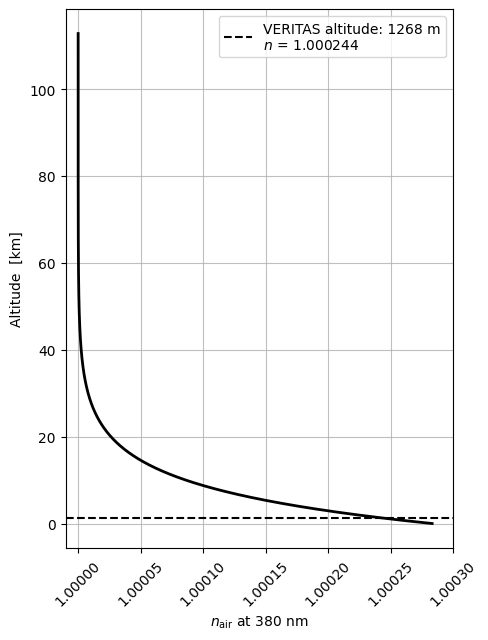

In [22]:
fig, ax = plt.subplots(figsize=(5, 7))

plt.plot(n_air(optimal_wvl, more_altitudes), more_altitudes / 1e3, c='black', lw=2)
plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m\n$n$ = %.6f' % (veritas_alt,
                                                           n_air(optimal_wvl, veritas_alt)))

plt.legend()
plt.grid(alpha=0.8)
# plt.title('Index of refraction as a function of altitude\n\n')
plt.xlabel(r'$n_\mathrm{air}$' + ' at {} nm'.format(int(optimal_wvl * 1e9)))

plt.xlim(xmin=1-1e-5)

ticks = ax.xaxis.axes.get_xticks()
ticks_str = [f'%.5f' % tick for tick in ticks]
plt.xticks(ticks=ticks[1:], labels=ticks_str[1:], rotation=45)
plt.ylabel('Altitude  [km]')

plt.show()

In [23]:
def d2Ndxdlam(lam, alt, beta, q=e_charge, mu=mu_air):

    return np.pi * q**2 * mu / c.h.value * (c.c.value / lam**2) * (1 - 1 / (beta * n_air(lam, alt))**2)

In [24]:
def dNdx(lam_low, lam_high, alt, beta, q=e_charge, mu=mu_air):

    return quad(d2Ndxdlam, lam_low, lam_high, args=(alt, beta, q, mu))[0]

In [25]:
def detect_d2Ndxdlam(lam, alt, beta, q=e_charge, mu=mu_air):

    return constant_efficiency_factor * qe_fct(lam) * ref_fct(lam) * d2Ndxdlam(lam, alt, beta, q, mu)

In [26]:
def detect_dNdx(lam_low, lam_high, alt, beta, q=e_charge, mu=mu_air):

    return quad(detect_d2Ndxdlam, lam_low, lam_high, args=(alt, beta, q, mu))[0]

In [27]:
def get_beta(E, m=c.m_e.value):

    return np.sqrt(1 - m**2 * c.c.value**4 / E**2)

In [28]:
def get_gamma(E, m=c.m_e.value):

    return E / (m * c.c.value**2)

In [29]:
def decay_prob(t, lifetime):

    return 1 - np.exp(-t / lifetime)

In [30]:
def decay_prob_dens(t, lifetime):

    return np.exp(-t / lifetime) / lifetime

In [31]:
def get_cherenkov_angle(beta, n):

    return np.arccos(1 / (beta * n))

In [32]:
# def get_detection_length(lam, beta):
    
#     n = n_air(lam)
#     angle = get_cherenkov_angle(beta, n)
    
#     length = D/2 / np.tan(angle)
#     if length < atmos_height:
#         return length
#     else:
#         return atmos_height

In [33]:
# def get_detection_length(lam, beta):
#     """Neglects any changing angle of incidence as photon crosses thicker layers of atmosphere"""

#     for h in np.linspace(atmos_height, veritas_alt, 10000):
#         n = n_air(lam, alt)
#         angle = get_cherenkov_angle(beta, n)
#         dist = (h - veritas_alt) * np.tan(angle)

#         if dist <= D/2:
#             return h
    
#     return veritas_alt

In [34]:
# def detect_N(lam_low, lam_high, beta, q=e_charge, mu=mu_air):

#     return dblquad(lambda x, w: d2Ndxdlam(w, x, beta, q, mu), 
#                    lam_low, lam_high, 
#                    veritas_alt, lambda w: get_detection_length(w, beta))[0]

In [35]:
# Unnecessary

def get_extent(alt, stop, dh, beta, lam):
    """Accounts for changing angle of incidence as photon crosses thicker layers of atmosphere"""
    
    if alt < stop:
        return np.nan
    
    ext = 0
    
    n1 = n_air(lam, alt)
    angle = get_cherenkov_angle(beta, n1)

    while alt > stop:

        ext += dh * np.tan(angle)
        
        alt -= dh
        n2 = n_air(lam, alt)
        angle = np.arcsin(n1 * np.sin(angle) / n2)
        n1 = n2

    return ext

In [36]:
def get_rel_intensity(phi, xi):

    radical = 1 - xi**2 * np.sin(phi)**2
    return np.sqrt(radical)

In [37]:
def get_impact_factor(xi):

    if xi > 1:
        bound = np.arcsin(1/xi)
    else:
        bound = np.pi/2
    
    integ = quad(get_rel_intensity, 0, bound, args=(xi))[0]
    return integ * 2 / np.pi

In [38]:
def get_arclength(xi, theta):

    # Returns arclentgh in degrees
    
    if xi >= 1:
        return 2 * np.arcsin(1/xi) * theta / np.pi * 180
    else:
        return 2 * np.pi * theta / np.pi * 180

In [39]:
# Minimum muon energy (in GeV) to emit Cherenkov radiation in air

max_n = n_air(UVB_UVC)

min_muon_gamma = (1 - max_n**-2) ** -0.5
min_muon_E = min_muon_gamma * muon_mass * c.c.value**2 * u.J.to(u.GeV)
min_muon_E

4.695933084286152

In [40]:
# Make arrays of muon energies

muon_E_span = np.logspace(np.log10(min_muon_E), np.log10(150e3), 10000)[1:]  # GeV
# muon_E_span = np.logspace(np.log10(min_muon_E), np.log10(150e3), 100)[1:]  # GeV
# muon_energies = np.array([4.9, 5, 6, 7, 10, 100, 1e3, 10e3])  # GeV
muon_energies = np.array([5.1, 5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8])  # GeV

In [41]:
# Time and distance arrays

times = np.linspace(0, 7e3 * muon_lifetime, 10000)
dists = np.linspace(0, atmos_height, 10000)

In [42]:
clrs = ['firebrick', 'darkorange', 'gold', 'lime', 'forestgreen', 'dodgerblue', 'blueviolet', 'fuchsia']

In [43]:
# test_altitudes = np.linspace(0, top_atmos_height, int(1e5))
test_altitudes = np.linspace(0, top_atmos_height, int(1e6))

# test_gammas = np.logspace(2, 5, 4)
test_gammas = np.array([10**1.7, 1e2, 1e3, 1e4, 1e5])
test_betas = np.sqrt(1 - test_gammas**-2)

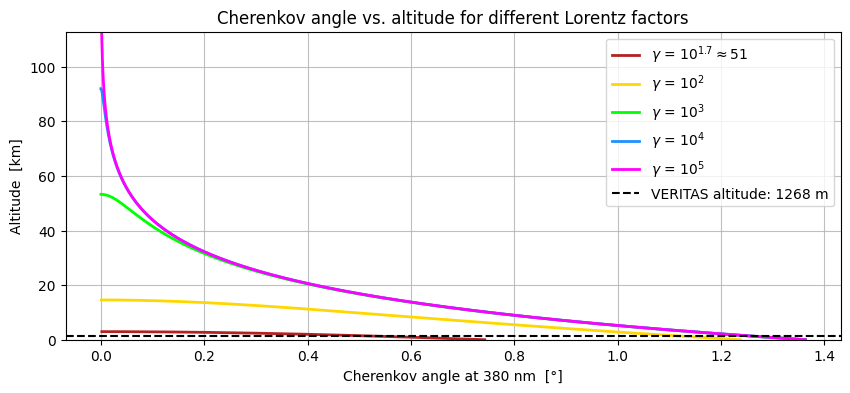

In [57]:
clrs2 = ['firebrick', 'gold', 'lime', 'dodgerblue', 'fuchsia']

fig, ax = plt.subplots(figsize=(10, 4))

for i, test_beta in enumerate(test_betas):

    test_angles = np.zeros_like(test_altitudes)
    for j, test_altitude in enumerate(test_altitudes):
        if test_beta > 1 / n_air(optimal_wvl, test_altitude):
            test_angles[j] = get_cherenkov_angle(test_beta, n=n_air(optimal_wvl, test_altitude))
        else:
            test_angles[j] = np.nan
            
    test_angles_deg = test_angles / np.pi * 180

    if i == 0:
        label = r'$\gamma$ = 10$^{1.7} \approx 51$'
    else:
        label=r'$\gamma$ = 10$^{}$'.format(int(np.log10(test_gammas[i])))

    plt.plot(test_angles_deg, test_altitudes / 1e3, c=clrs2[i], lw=2, label=label)

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel('Cherenkov angle at {} nm  [°]'.format(int(optimal_wvl * 1e9)))
plt.title('Cherenkov angle vs. altitude for different Lorentz factors')

plt.ylim(0, top_atmos_height/1e3)

plt.legend()
plt.show()

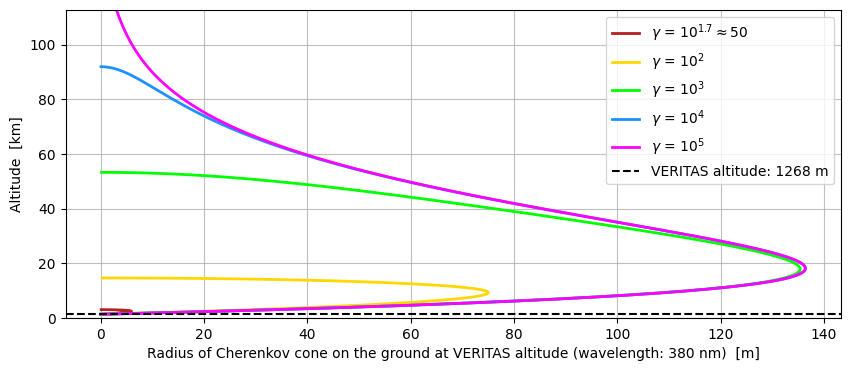

In [69]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_beta in enumerate(test_betas):

    test_angles = np.zeros_like(test_altitudes)
    for j, test_altitude in enumerate(test_altitudes):
        if test_beta > 1 / n_air(optimal_wvl, test_altitude):
            test_angles[j] = get_cherenkov_angle(test_beta, n=n_air(optimal_wvl, test_altitude))
        else:
            test_angles[j] = np.nan
            
    test_extents = (test_altitudes - veritas_alt) * np.tan(test_angles)
    test_extents[test_extents < 0] = np.nan  # do not accept heights lower than VERITAS altitude

    if i == 0:
        label = r'$\gamma$ = 10$^{1.7} \approx 50$'
    else:
        label=r'$\gamma$ = 10$^{}$'.format(int(np.log10(test_gammas[i])))
    
    plt.plot(test_extents, test_altitudes/1e3, c=clrs2[i], lw=2, 
             label=label)

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel('Radius of Cherenkov cone on the ground at VERITAS altitude (wavelength: {} nm)  [m]'.format(int(optimal_wvl * 1e9)))
# plt.title('Cherenkov cone radius vs. altitude for different Lorentz factors')

plt.ylim(0, top_atmos_height/1e3)

plt.legend()
plt.show()

In [71]:
np.max(test_extents[test_extents > 0])

136.39258515172077

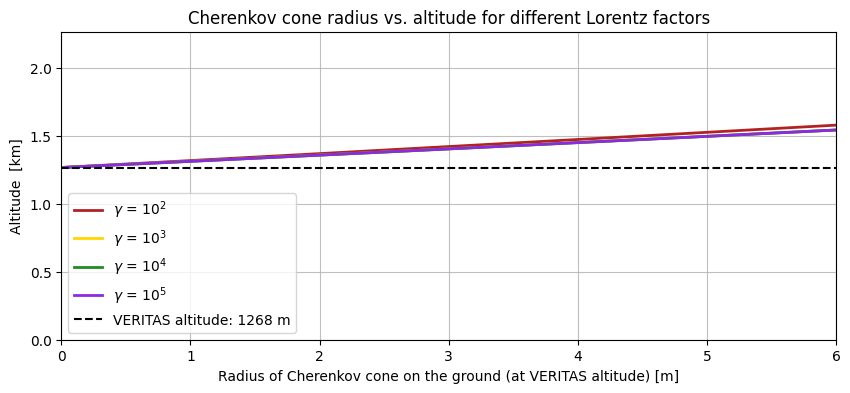

In [42]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_beta in enumerate(test_betas):

    test_angles = np.zeros_like(test_altitudes)
    for j, test_altitude in enumerate(test_altitudes):
        if test_beta > 1 / n_air(optimal_wvl, test_altitude):
            test_angles[j] = get_cherenkov_angle(test_beta, n=n_air(optimal_wvl, test_altitude))
        else:
            test_angles[j] = np.nan
            
    test_extents = (test_altitudes - veritas_alt) * np.tan(test_angles)
    test_extents[test_extents < 0] = np.nan  # do not accept heights lower than VERITAS altitude

    plt.plot(test_extents, test_altitudes/1e3, c=clrs[::2][i], lw=2, 
             label=r'$\gamma$ = 10$^{}$'.format(int(np.log10(test_gammas[i]))))

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel('Radius of Cherenkov cone on the ground (at VERITAS altitude) [m]')
plt.title('Cherenkov cone radius vs. altitude for different Lorentz factors')

plt.ylim(0, veritas_alt/1e3 + 1)
plt.xlim(0, D/2)

plt.legend()
plt.show()

In [43]:
# fig, ax = plt.subplots(figsize=(10, 4))

# for i, test_beta in enumerate(test_betas):

#     test_extents = np.zeros_like(test_altitudes)
#     for j, test_altitude in enumerate(test_altitudes):
#         if test_beta > 1 / n_air(optimal_wvl, test_altitude):
#             test_extents[j] = get_extent(test_altitude, veritas_alt, 10, test_beta, optimal_wvl)
#         else:
#             test_extents[j] = np.nan

#     plt.plot(test_extents, test_altitudes/1e3, c=clrs[::2][i], lw=2, 
#              label=r'$\gamma$ = 10$^{}$'.format(int(np.log10(test_gammas[i]))))

# plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
#             label=f'VERITAS altitude: %i m' % veritas_alt)

# plt.grid(alpha=0.8)
# plt.ylabel('Altitude  [km]')
# plt.xlabel('Radius of Cherenkov cone on the ground (at VERITAS altitude) [m]')
# plt.title('Cherenkov cone radius vs. altitude for different Lorentz factors')

# plt.ylim(0, top_atmos_height/1e3)

# plt.legend()
# plt.show()

In [48]:
all_test_angles_deg = []
all_test_extents = []
# all_test_ring_intensities = []

for i, test_energy in enumerate(muon_energies):

    test_beta = get_beta(test_energy * u.GeV.to(u.J), muon_mass)

    test_angles = np.zeros_like(test_altitudes)
    for j, test_altitude in enumerate(test_altitudes):
        if test_beta > 1 / n_air(optimal_wvl, test_altitude):
            test_angles[j] = get_cherenkov_angle(test_beta, n=n_air(optimal_wvl, test_altitude))
        else:
            test_angles[j] = np.nan
            
    test_angles_deg = test_angles / np.pi * 180
    all_test_angles_deg.append(test_angles_deg)
            
    test_extents = (test_altitudes - veritas_alt) * np.tan(test_angles)
    test_extents[test_extents < 0] = np.nan  # do not accept heights lower than VERITAS altitude
    all_test_extents.append(test_extents)

    # test_ring_intensities = np.zeros_like(test_altitudes)
    # wavelengths = np.linspace(PMT_max, UVB_UVC, 1000)

    # for j, test_altitude in enumerate(test_altitudes):
    #     okay = True
    #     k = 0
    #     max_wavelength = wavelengths[k]
        
    #     while okay and not test_beta > 1 / n_air(max_wavelength, test_altitude):
    #         k += 1
    #         try:
    #             max_wavelength = wavelengths[k]
    #         except:
    #             okay = False
            
    #     if okay:
    #         # test_ring_intensities[j] = detect_dNdx(lam_low=UVB_UVC, lam_high=max_wavelength, alt=test_altitude, beta=test_beta)
    #         test_ring_intensities[j] = dNdx(lam_low=UVB_UVC, lam_high=max_wavelength, alt=test_altitude, beta=test_beta)
    #     else:
    #         test_ring_intensities[j] = 0  # No Cherenkov photons in the range of PMT sensitivity

    # all_test_ring_intensities.append(test_ring_intensities)

In [45]:
# # all_test_angles_deg = []
# # all_test_extents = []
# all_test_ring_intensities = []

# for i, test_energy in enumerate(muon_energies):

#     test_beta = get_beta(test_energy * u.GeV.to(u.J), muon_mass)

#     # test_angles = np.zeros_like(test_altitudes)
#     # for j, test_altitude in enumerate(test_altitudes):
#     #     if test_beta > 1 / n_air(optimal_wvl, test_altitude):
#     #         test_angles[j] = get_cherenkov_angle(test_beta, n=n_air(optimal_wvl, test_altitude))
#     #     else:
#     #         test_angles[j] = np.nan
            
#     # test_angles_deg = test_angles / np.pi * 180
#     # all_test_angles_deg.append(test_angles_deg)
            
#     # test_extents = (test_altitudes - veritas_alt) * np.tan(test_angles)
#     # test_extents[test_extents < 0] = np.nan  # do not accept heights lower than VERITAS altitude
#     # all_test_extents.append(test_extents)

#     test_ring_intensities = np.zeros_like(test_altitudes)
#     wavelengths = np.linspace(PMT_max, UVB_UVC, 1000)

#     for j, test_altitude in enumerate(test_altitudes):
#         okay = True
#         k = 0
#         max_wavelength = wavelengths[k]
        
#         while okay and not test_beta > 1 / n_air(max_wavelength, test_altitude):
#             k += 1
#             try:
#                 max_wavelength = wavelengths[k]
#             except:
#                 okay = False
            
#         if okay:
#             # test_ring_intensities[j] = detect_dNdx(lam_low=UVB_UVC, lam_high=max_wavelength, alt=test_altitude, beta=test_beta)
#             test_ring_intensities[j] = dNdx(lam_low=UVB_UVC, lam_high=max_wavelength, alt=test_altitude, beta=test_beta)
#         else:
#             test_ring_intensities[j] = 0  # No Cherenkov photons in the range of PMT sensitivity

#     all_test_ring_intensities.append(test_ring_intensities)

In [44]:
directory = 'output/'

# np.save(directory + 'muon_E_full_atm.npy', muon_energies)
# np.save(directory + 'altitudes_full_atm.npy', test_altitudes)
# np.save(directory + 'ring_radii_full_atm.npy', np.array(all_test_angles_deg))
# np.save(directory + 'extents_full_atm.npy', np.array(all_test_extents))
# np.save(directory + 'muon_ring_sizes_full_atm.npy', np.array(all_test_ring_intensities))

muon_energies = np.load(directory + 'muon_E_full_atm.npy')
test_altitudes = np.load(directory + 'altitudes_full_atm.npy')
all_test_angles_deg = np.load(directory + 'ring_radii_full_atm.npy')
all_test_extents = np.load(directory + 'extents_full_atm.npy')
all_test_ring_intensities = np.load(directory + 'muon_ring_sizes_full_atm.npy')

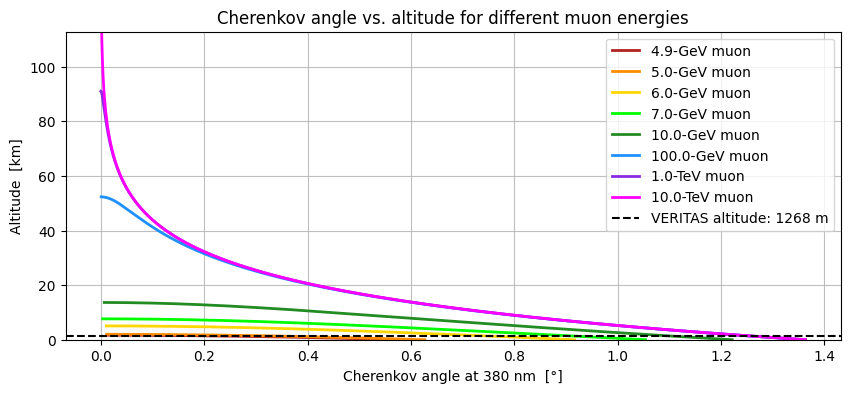

In [45]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):

    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)

    plt.plot(all_test_angles_deg[i], test_altitudes / 1e3, c=clrs[i], lw=2, label=label)

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel('Cherenkov angle at {} nm  [°]'.format(int(optimal_wvl * 1e9)))
plt.title('Cherenkov angle vs. altitude for different muon energies')

plt.ylim(0, top_atmos_height/1e3)

plt.legend()
plt.show()

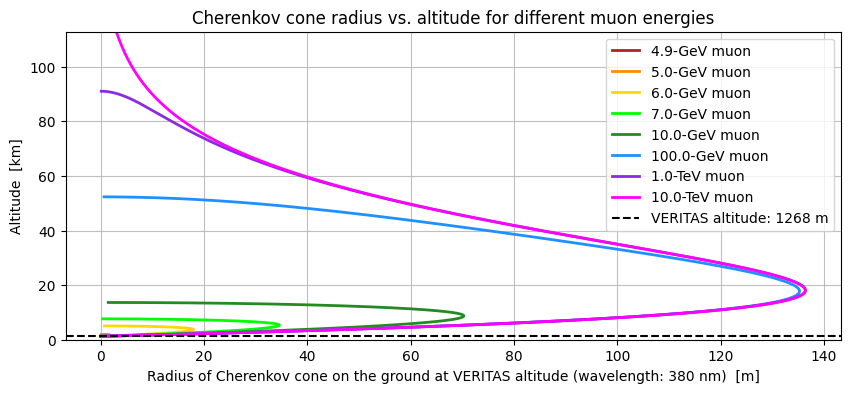

In [46]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):

    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_test_extents[i], test_altitudes/1e3, c=clrs[i], lw=2, label=label)

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel('Radius of Cherenkov cone on the ground at VERITAS altitude (wavelength: {} nm)  [m]'.format(int(optimal_wvl * 1e9)))
plt.title('Cherenkov cone radius vs. altitude for different muon energies')

plt.ylim(0, top_atmos_height/1e3)

plt.legend()
plt.show()

In [47]:
get_cherenkov_angle(get_beta(10**1.7 * muon_mass * c.c.value**2, muon_mass), n_air(optimal_wvl, veritas_alt)) / np.pi *180

0.5398327508243503

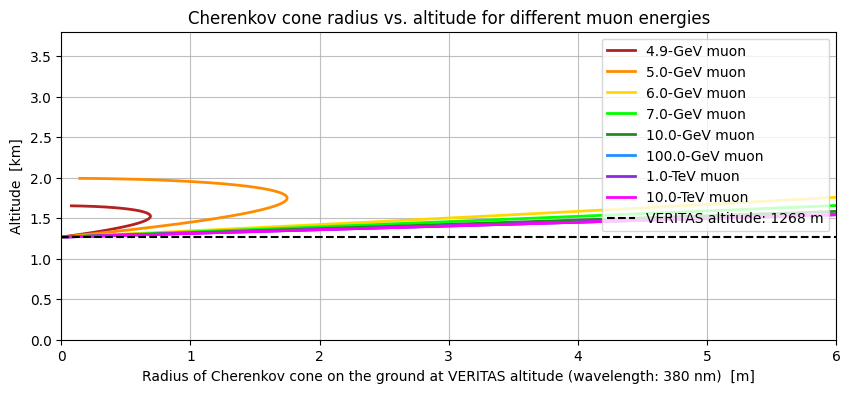

In [48]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):

    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_test_extents[i], test_altitudes/1e3, c=clrs[i], lw=2, label=label)

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel('Radius of Cherenkov cone on the ground at VERITAS altitude (wavelength: {} nm)  [m]'.format(int(optimal_wvl * 1e9)))
plt.title('Cherenkov cone radius vs. altitude for different muon energies')

plt.ylim(0, veritas_alt/1e3 * 3)
plt.xlim(0, D/2)

plt.legend(loc='upper right')
plt.show()

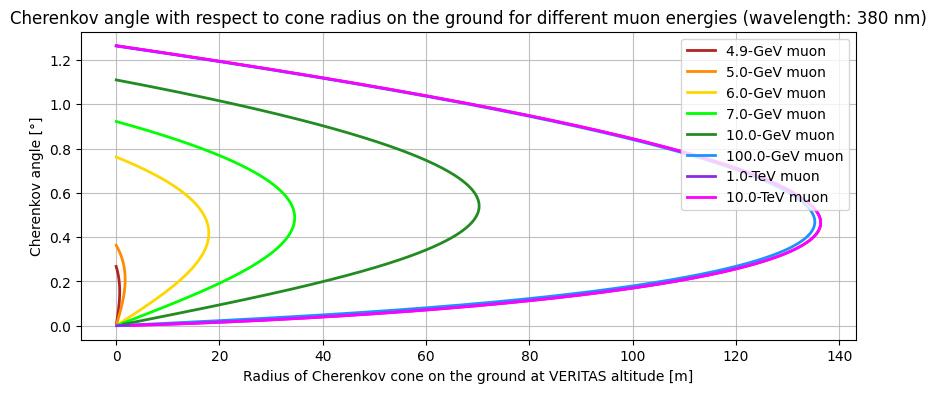

In [49]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):

    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_test_extents[i], all_test_angles_deg[i], c=clrs[i], lw=2, label=label)

plt.grid(alpha=0.8)
plt.ylabel('Cherenkov angle [°]')
plt.xlabel('Radius of Cherenkov cone on the ground at VERITAS altitude [m]')
plt.title('Cherenkov angle with respect to cone radius on the ground ' 
          + 'for different muon energies (wavelength: {} nm)'.format(int(optimal_wvl * 1e9)))

plt.legend(loc='upper right')
plt.show()

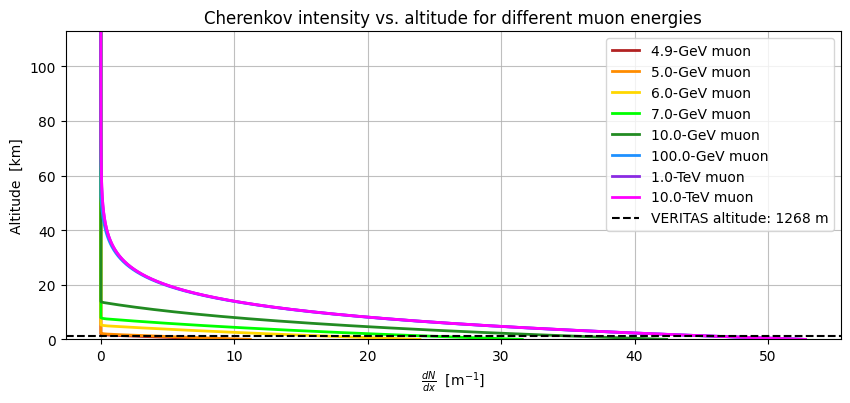

In [50]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):
    
    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_test_ring_intensities[i], test_altitudes/1e3, c=clrs[i], lw=2, label=label)

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel(r'$\frac{dN}{dx}$  [m$^{-1}$]')
plt.title('Cherenkov intensity vs. altitude for different muon energies')

plt.ylim(0, top_atmos_height/1e3)

plt.legend()
plt.show()

/Users/Leo/opt/anaconda3/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


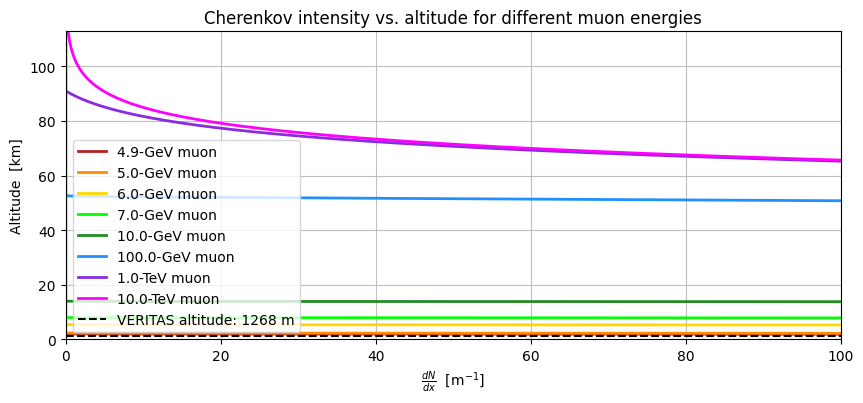

In [52]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):
    
    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_test_ring_intensities[i] * 4697, test_altitudes/1e3, c=clrs[i], lw=2, label=label)

plt.axhline(y=veritas_alt / 1e3, c='black', ls='--', lw=1.5, 
            label=f'VERITAS altitude: %i m' % veritas_alt)

plt.grid(alpha=0.8)
plt.ylabel('Altitude  [km]')
plt.xlabel(r'$\frac{dN}{dx}$  [m$^{-1}$]')
plt.title('Cherenkov intensity vs. altitude for different muon energies')

plt.ylim(0, top_atmos_height/1e3)
plt.xlim(0, 100)

plt.legend()
plt.show()

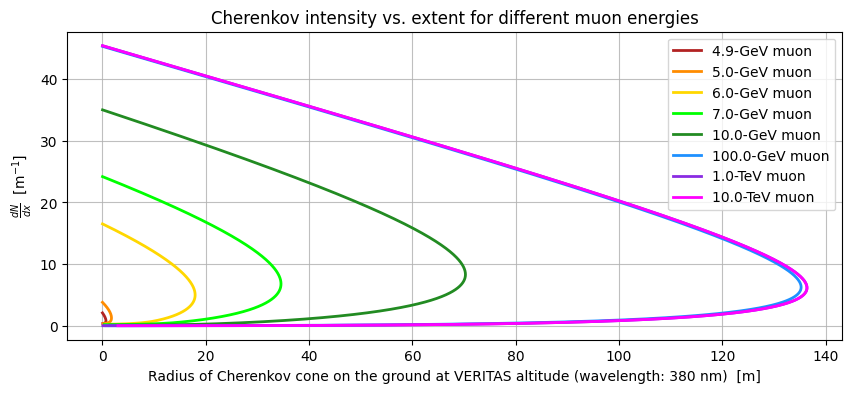

In [51]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):
    
    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_test_extents[i], all_test_ring_intensities[i], c=clrs[i], lw=2, label=label)
    
plt.grid(alpha=0.8)
plt.xlabel('Radius of Cherenkov cone on the ground at VERITAS altitude (wavelength: {} nm)  [m]'.format(int(optimal_wvl * 1e9)))
plt.ylabel(r'$\frac{dN}{dx}$  [m$^{-1}$]')
plt.title('Cherenkov intensity vs. extent for different muon energies')

plt.legend()
plt.show()

In [53]:
all_max_extents = []
all_test_extents_1 = []
all_test_extents_2 = []
all_test_angles_1 = []
all_test_angles_2 = []
radius_to_angle_1 = []
radius_to_angle_2 = []

for i in range(len(muon_energies)):
    
    clean_test_extents = all_test_extents[i][all_test_angles_deg[i] * all_test_extents[i] > 0]
    all_max_extents.append(np.max(clean_test_extents))
    
    clean_test_angles_deg = all_test_angles_deg[i][all_test_angles_deg[i] * all_test_extents[i] > 0]
    clean_test_angles = clean_test_angles_deg / 180 * np.pi

    index = np.argmax(clean_test_extents)
    clean_test_extents_1 = clean_test_extents[:index]
    clean_test_extents_2 = clean_test_extents[index+1:]
    clean_test_angles_1 = clean_test_angles[:index]
    clean_test_angles_2 = clean_test_angles[index+1:]
    
    all_test_extents_1.append(clean_test_extents_1)
    all_test_extents_2.append(clean_test_extents_2)
    all_test_angles_1.append(clean_test_angles_1)
    all_test_angles_2.append(clean_test_angles_2)

    function_1 = CubicSpline(clean_test_extents_1, clean_test_angles_1)
    function_2 = CubicSpline(clean_test_extents_2[::-1], clean_test_angles_2[::-1])

    radius_to_angle_1.append(function_1)
    radius_to_angle_2.append(function_2)

In [54]:
f = lambda lam: constant_efficiency_factor * qe_fct(lam) * ref_fct(lam) * lam**-2
U0 = np.pi * c.alpha.value * D * quad(f, UVB_UVC, PMT_max)[0]

In [55]:
# The following three assumptions must be made:

# - small angle approximation of Cherenkov angle
# - n varies weakly with wavelength (between UVB_UVC and PMT_max)
# - n varies weakly with height (over the relevant height integrated, which depends on Cherenkov angle)

all_impact_params = []
all_N_1 = []
all_N_2 = []
all_arclengths_1 = []
all_arclengths_2 = []

for i in range(len(muon_energies)):

    impact_params = np.linspace(0, all_max_extents[i], 10000)
    xis = impact_params / (D/2)
    interpolated_angles_1 = radius_to_angle_1[i](impact_params)
    interpolated_angles_2 = radius_to_angle_2[i](impact_params)

    interpolated_angles_1[interpolated_angles_1 < 0] = np.nan
    interpolated_angles_2[interpolated_angles_2 < 0] = np.nan
    
    N_1 = np.zeros_like(xis)
    N_2 = np.zeros_like(xis)
    arclengths_1 = np.zeros_like(xis)
    arclengths_2 = np.zeros_like(xis)
    
    for j, xi in tqdm(enumerate(xis)): 
        N_1[j] = U0 * interpolated_angles_1[j] * get_impact_factor(xi)
        N_2[j] = U0 * interpolated_angles_2[j] * get_impact_factor(xi)
        arclengths_1[j] = get_arclength(xi, interpolated_angles_1[j])
        arclengths_2[j] = get_arclength(xi, interpolated_angles_2[j])

    all_impact_params.append(impact_params)
    all_N_1.append(N_1)
    all_N_2.append(N_2)
    all_arclengths_1.append(arclengths_1)
    all_arclengths_2.append(arclengths_2)

10000it [00:02, 4771.61it/s]
10000it [00:02, 4544.87it/s]
10000it [00:13, 724.87it/s]
10000it [00:16, 622.07it/s]
10000it [00:18, 555.01it/s]
10000it [00:17, 556.12it/s]
10000it [00:19, 518.97it/s]
10000it [00:17, 568.33it/s]


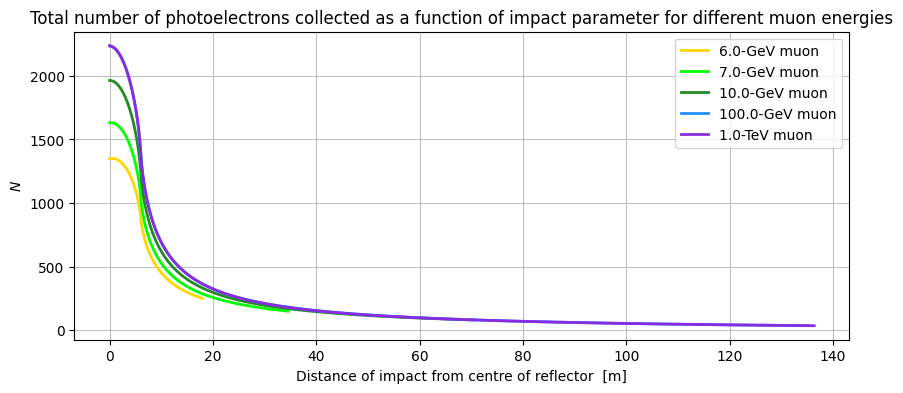

In [56]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):

    if i in [0, 1, 7]:
        continue
    
    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_impact_params[i], all_N_1[i] + all_N_2[i], c=clrs[i], lw=2, label=label)
    
plt.grid(alpha=0.8)
plt.ylabel(r'$N$')
plt.xlabel('Distance of impact from centre of reflector  [m]')
plt.title('Total number of photoelectrons collected as a function of impact parameter for different muon energies')

plt.legend()
plt.show()

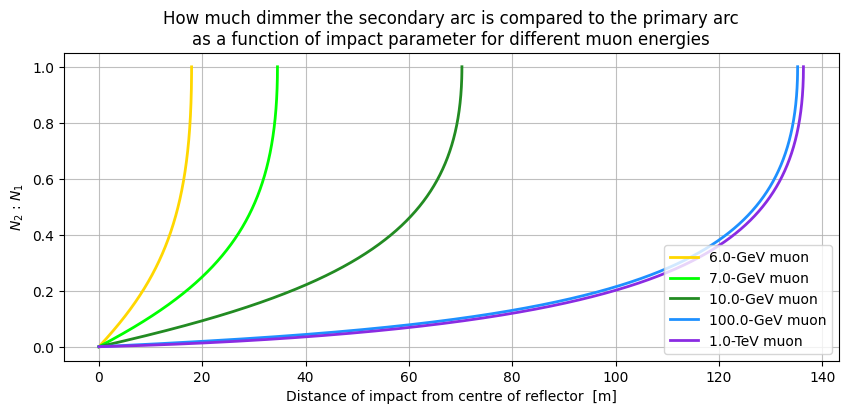

In [84]:
fig, ax = plt.subplots(figsize=(10, 4))

for i, test_energy in enumerate(muon_energies):

    if i in [0, 1, 7]:
        continue
    
    if test_energy < 1e3:
        label = f'%.1f-GeV muon' % test_energy
    else:
        label = f'%.1f-TeV muon' % (test_energy/1e3)
    
    plt.plot(all_impact_params[i], all_N_2[i] / all_N_1[i], c=clrs[i], lw=2, label=label)
    
plt.grid(alpha=0.8)
plt.ylabel(r'$N_2$ : $N_1$')
plt.xlabel('Distance of impact from centre of reflector  [m]')
plt.title('How much dimmer the secondary arc is compared to the primary arc'
          + '\nas a function of impact parameter for different muon energies')

plt.legend(loc='lower right')
plt.show()

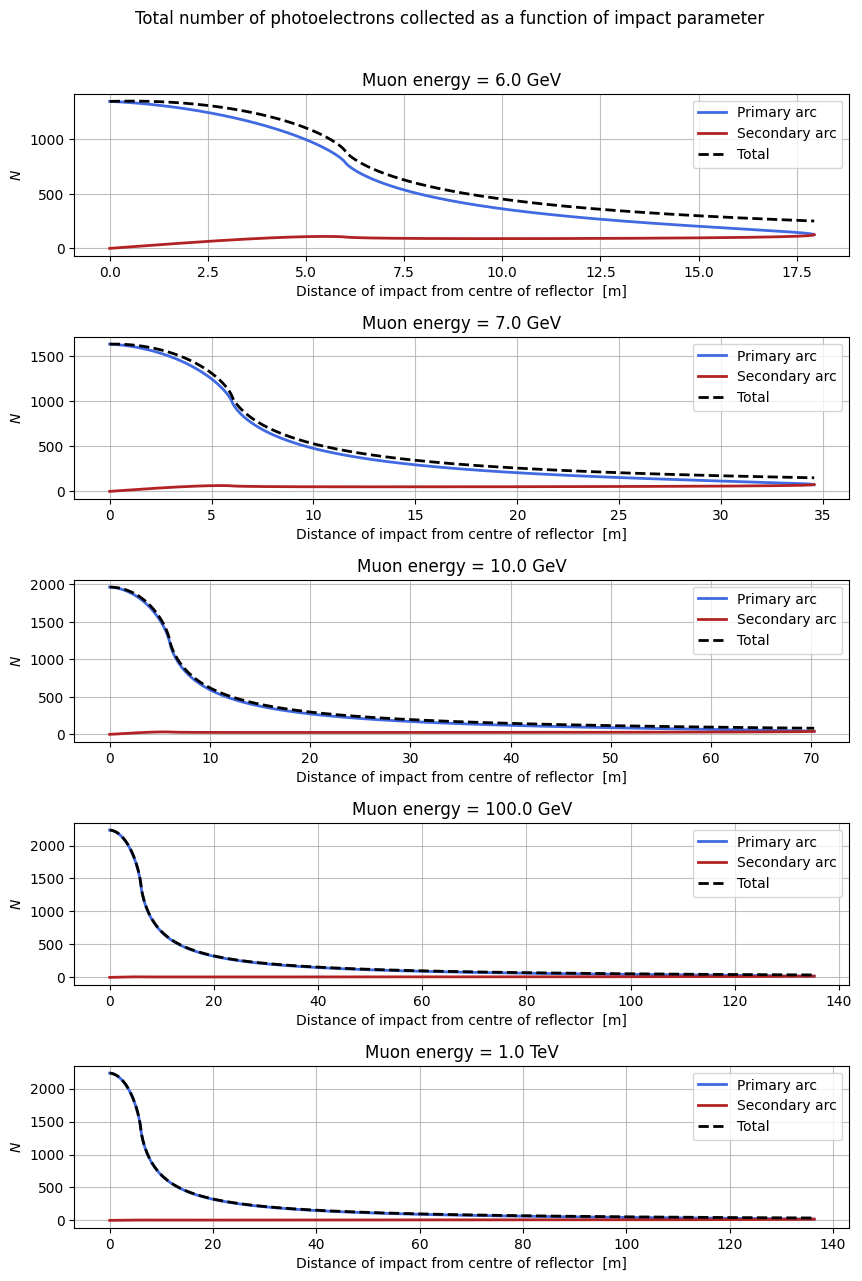

In [58]:
plt.figure(figsize=(10, 14))
plt.subplots_adjust(hspace=0.5, top=0.92)

n = 1
for i, test_energy in enumerate(muon_energies):

    if i in [0, 1, 7]:
        continue

    if test_energy < 1e3:
        label = f'%.1f GeV' % test_energy
    else:
        label = f'%.1f TeV' % (test_energy/1e3)
    
    plt.subplot(len(muon_energies) - 3, 1, n)    
    
    plt.plot(all_impact_params[i], all_N_1[i], c='royalblue', lw=2, label='Primary arc')
    plt.plot(all_impact_params[i], all_N_2[i], c='firebrick', lw=2, label='Secondary arc')
    plt.plot(all_impact_params[i], all_N_1[i] + all_N_2[i], c='black', ls='--', lw=2, label='Total')
    
    plt.grid(alpha=0.8)
    plt.legend()
    plt.ylabel(r'$N$')
    plt.xlabel('Distance of impact from centre of reflector  [m]')
    plt.title('Muon energy = {}'.format(label))

    n += 1

plt.suptitle('Total number of photoelectrons collected as a function of impact parameter')
plt.show()

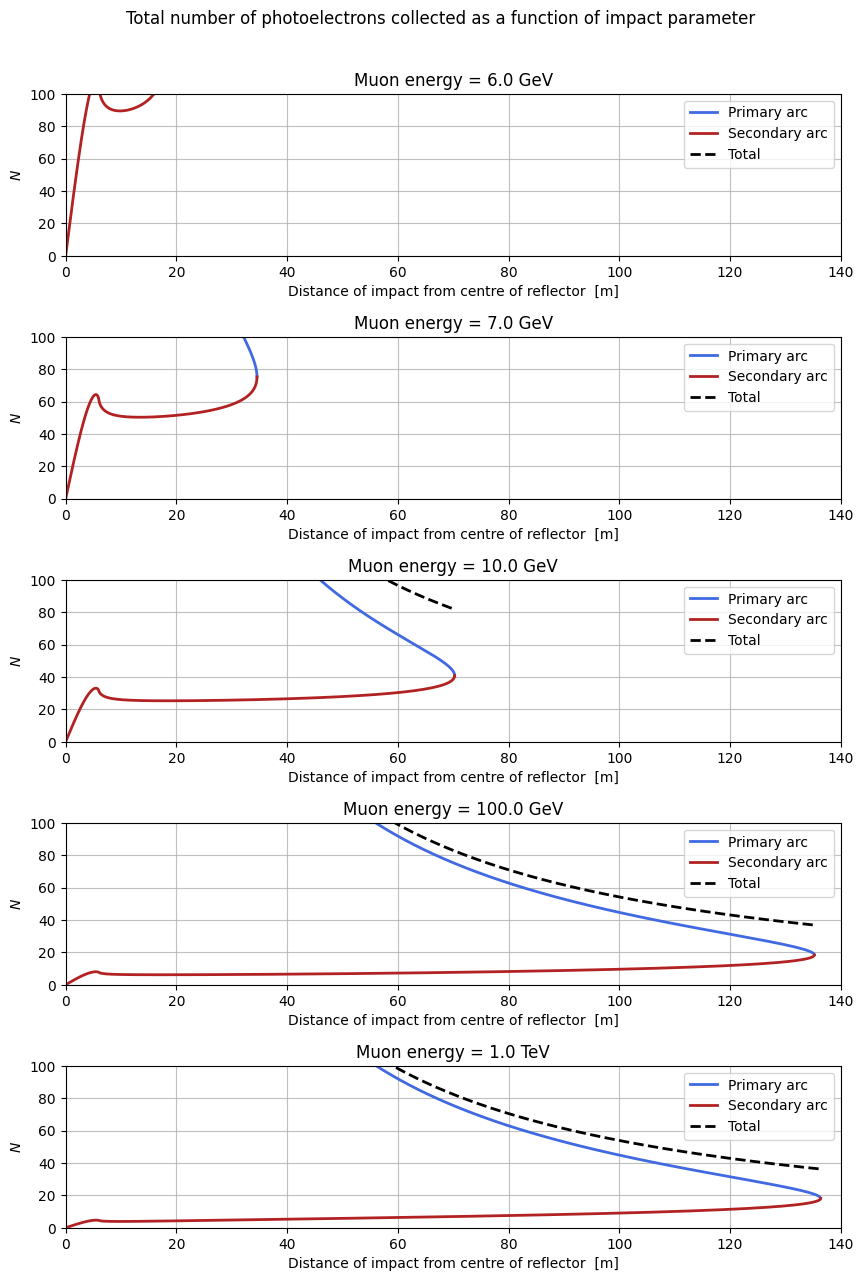

In [83]:
plt.figure(figsize=(10, 14))
plt.subplots_adjust(hspace=0.5, top=0.92)

n = 1
for i, test_energy in enumerate(muon_energies):

    if i in [0, 1, 7]:
        continue

    if test_energy < 1e3:
        label = f'%.1f GeV' % test_energy
    else:
        label = f'%.1f TeV' % (test_energy/1e3)
    
    plt.subplot(len(muon_energies) - 3, 1, n)    
    
    plt.plot(all_impact_params[i], all_N_1[i], c='royalblue', lw=2, label='Primary arc')
    plt.plot(all_impact_params[i], all_N_2[i], c='firebrick', lw=2, label='Secondary arc')
    plt.plot(all_impact_params[i], all_N_1[i] + all_N_2[i], c='black', ls='--', lw=2, label='Total')
    
    plt.grid(alpha=0.8)
    plt.legend()
    plt.ylabel(r'$N$')
    plt.xlabel('Distance of impact from centre of reflector  [m]')
    plt.title('Muon energy = {}'.format(label))

    n += 1

    plt.ylim(0, 100)
    plt.xlim(0, 140)

plt.suptitle('Total number of photoelectrons collected as a function of impact parameter')
plt.show()

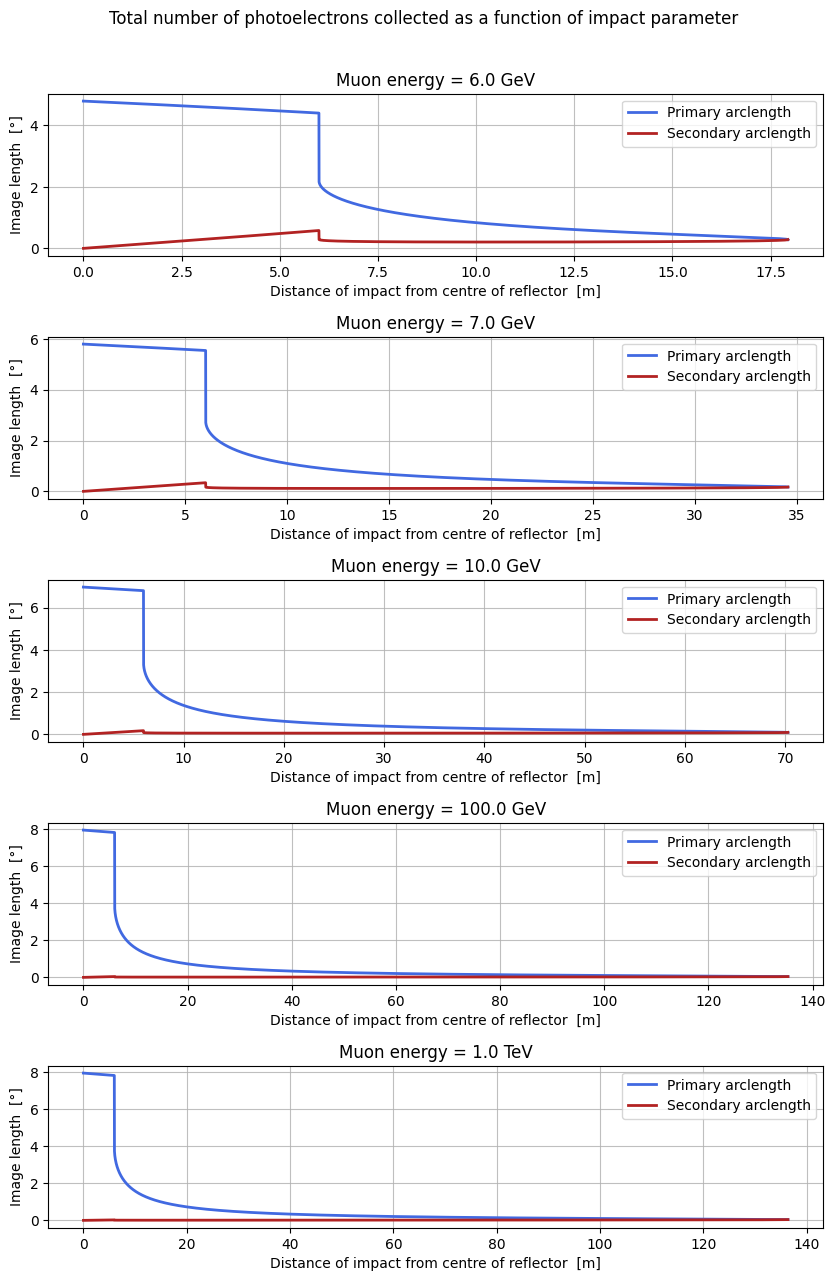

In [78]:
plt.figure(figsize=(10, 14))
plt.subplots_adjust(hspace=0.5, top=0.92)

n = 1
for i, test_energy in enumerate(muon_energies):

    if i in [0, 1, 7]:
        continue

    if test_energy < 1e3:
        label = f'%.1f GeV' % test_energy
    else:
        label = f'%.1f TeV' % (test_energy/1e3)
    
    plt.subplot(len(muon_energies) - 3, 1, n)    
    
    plt.plot(all_impact_params[i], all_arclengths_1[i], c='royalblue', lw=2, label='Primary arclength')
    plt.plot(all_impact_params[i], all_arclengths_2[i], c='firebrick', lw=2, label='Secondary arclength')

    # interpolated_angles_1 = radius_to_angle_1[i](all_impact_params[i]) / np.pi * 180
    # interpolated_angles_2 = radius_to_angle_2[i](all_impact_params[i]) / np.pi * 180

    # interpolated_angles_1[interpolated_angles_1 < 0] = np.nan
    # interpolated_angles_2[interpolated_angles_2 < 0] = np.nan
    
    # plt.plot(all_impact_params[i], interpolated_angles_1, c='dodgerblue', ls='--', lw=2, label='Primary radius')
    # plt.plot(all_impact_params[i], interpolated_angles_2, c='red', ls='--', lw=2, label='Secondary radius')
    
    plt.grid(alpha=0.8)
    plt.legend()
    plt.ylabel('Image length  [°]')
    plt.xlabel('Distance of impact from centre of reflector  [m]')
    plt.title('Muon energy = {}'.format(label))

    n += 1

plt.suptitle('Total number of photoelectrons collected as a function of impact parameter')
plt.show()

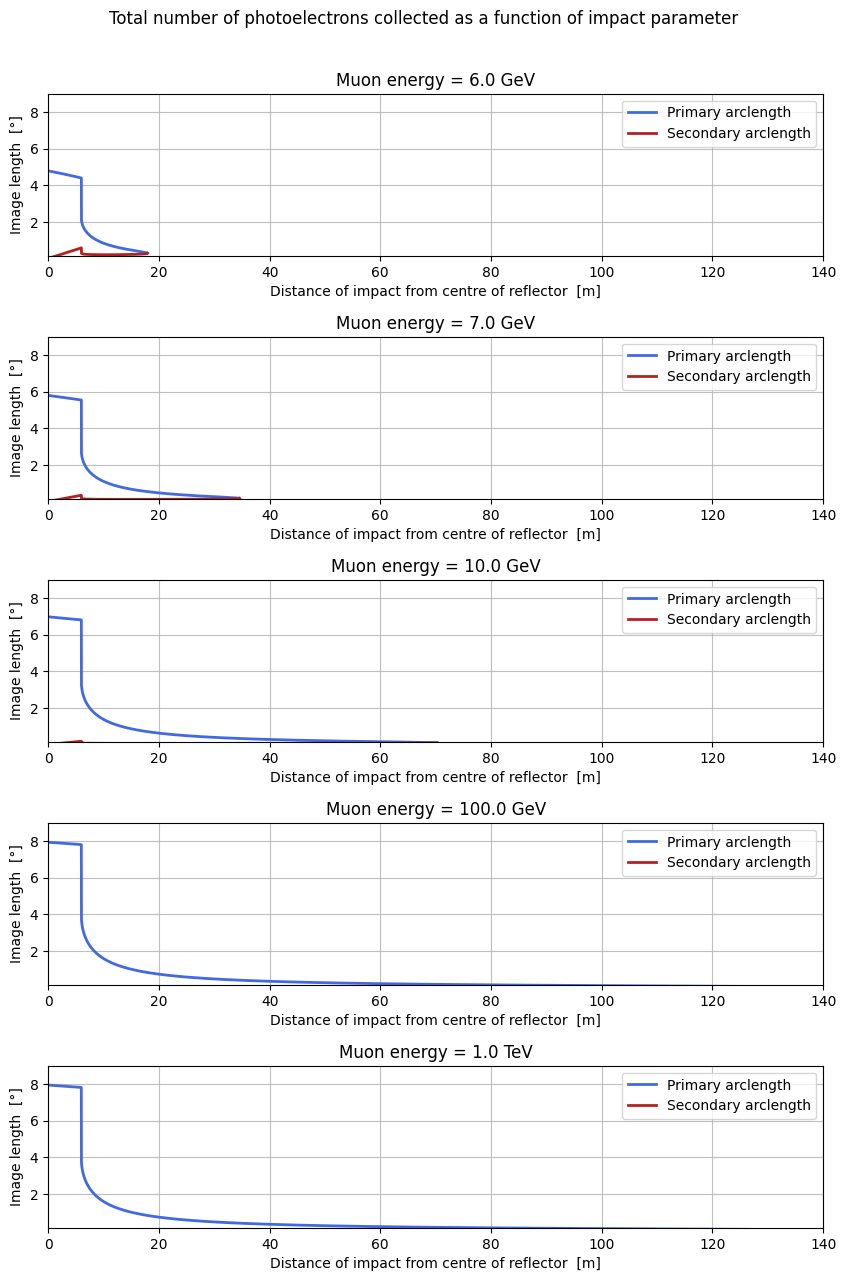

In [85]:
plt.figure(figsize=(10, 14))
plt.subplots_adjust(hspace=0.5, top=0.92)

n = 1
for i, test_energy in enumerate(muon_energies):

    if i in [0, 1, 7]:
        continue

    if test_energy < 1e3:
        label = f'%.1f GeV' % test_energy
    else:
        label = f'%.1f TeV' % (test_energy/1e3)
    
    plt.subplot(len(muon_energies) - 3, 1, n)    
    
    plt.plot(all_impact_params[i], all_arclengths_1[i], c='royalblue', lw=2, label='Primary arclength')
    plt.plot(all_impact_params[i], all_arclengths_2[i], c='firebrick', lw=2, label='Secondary arclength')

    # interpolated_angles_1 = radius_to_angle_1[i](all_impact_params[i]) / np.pi * 180
    # interpolated_angles_2 = radius_to_angle_2[i](all_impact_params[i]) / np.pi * 180

    # interpolated_angles_1[interpolated_angles_1 < 0] = np.nan
    # interpolated_angles_2[interpolated_angles_2 < 0] = np.nan
    
    # plt.plot(all_impact_params[i], interpolated_angles_1, c='dodgerblue', ls='--', lw=2, label='Primary radius')
    # plt.plot(all_impact_params[i], interpolated_angles_2, c='red', ls='--', lw=2, label='Secondary radius')
    
    plt.grid(alpha=0.8)
    plt.legend()
    plt.ylabel('Image length  [°]')
    plt.xlabel('Distance of impact from centre of reflector  [m]')
    plt.title('Muon energy = {}'.format(label))

    n += 1

    plt.xlim(0, 140)
    plt.ylim(0.15, 9)

plt.suptitle('Total number of photoelectrons collected as a function of impact parameter')
plt.show()

In [62]:
# # Calculate Cherenkov angles = muon ring radius (angular size)

# betas = get_beta(E=muon_E_span * u.GeV.to(u.J), m=muon_mass)

# angles = np.zeros_like(betas)
# for i, beta in enumerate(betas):
#     if beta > 1 / n_air(optimal_wvl, veritas_alt):
#         angles[i] = get_cherenkov_angle(beta, n=n_air(optimal_wvl, veritas_alt))
#     else:
#         angles[i] = np.nan
        
# angles_deg = angles / np.pi * 180

In [63]:
# fig, ax = plt.subplots(figsize=(10, 4))

# plt.plot(muon_E_span, angles_deg, c='firebrick', lw=2)

# plt.grid(alpha=0.8)
# plt.xlabel('Muon energy  [GeV]')
# plt.ylabel('Cherenkov angle at {} nm near the ground  [°]'.format(int(optimal_wvl * 1e9)))
# plt.title('Muon ring radius as a function of its energy')

# plt.show()

In [64]:
# restricted_betas = betas[0:2200:20]
# restricted_muon_E_span = muon_E_span[0:2200:20]
# restricted_angles_deg = angles_deg[0:2200:20]

In [65]:
# fig, ax = plt.subplots(figsize=(10, 4))

# plt.plot(restricted_muon_E_span, restricted_angles_deg, c='firebrick', lw=2)
# plt.axvline(x=min_muon_E, color='black', ls='--', lw=1.5, alpha=0.6,
#             label=r'Minimum energy to induce Cherenkov radiation ($E$ = {} GeV)'.format(round(min_muon_E, 2)))

# plt.grid(alpha=0.8)
# plt.xlabel('Muon energy  [GeV]')
# plt.ylabel('Cherenkov angle at {} nm near the ground  [°]'.format(int(optimal_wvl * 1e9)))
# plt.title('Muon ring radius as a function of its energy')

# plt.xscale('log')

# plt.legend()
# plt.show()

In [66]:
# Note that, where Cherenkov angle is rapidly changing (low energies),
# angle might be modestly increasing with Cherenkov photon wavelength
# due to the weak dependence of n on wavelength.

In [67]:
# # Calculate Cherenkov angles for specific muon energies

# some_betas = get_beta(E=muon_energies * u.GeV.to(u.J), m=muon_mass)
# some_angles = get_cherenkov_angle(some_betas, n=n_air(optimal_wvl, veritas_alt))
# some_angles_deg = some_angles / np.pi * 180

In [68]:
# print('Muon ring radii at {} nm near the ground (VERITAS altitude):'.format(int(optimal_wvl * 1e9)))
# for i, E in enumerate(muon_energies):
#     if E < 1e3:
#         text = str(int(E)) + '-GeV muon:'
#     else:
#         text = str(int(E/1e3)) + '-TeV muon:'
#     print(text, str(round(some_angles_deg[i], 4)) + '°')

In [69]:
# # Double integration with conditionals = do not rely on quad

# true_ring_intensities = np.zeros_like(restricted_betas)

# dw = 1e-10  # m
# wavelengths = np.arange(UVB_UVC, PMT_max, dw)

# dx = 1e-1  # m
# heights = np.arange(veritas_alt, atmos_height, dx)

# for i, beta in enumerate(restricted_betas):
    
#     s = 0
    
#     #  for height in tqdm(heights):
#     for height in heights:
       
#         h = height + dx/2

#         for wavelength in reversed(wavelengths):

#             w = wavelength + dw/2
            
#             if beta > 1 / n_air(w, h):
#                 extent = get_extent(alt=height, stop=veritas_alt, dh=dx, beta=beta, lam=w)

#                 if extent <= D/2:
#                     s += detect_d2Ndxdlam(lam=w, alt=h, beta=beta) * dw * dx
        
#     true_ring_intensities[i] = s

In [70]:
# directory = 'output/'

# # np.save(directory + 'muon_E_PT.npy', restricted_muon_E_span)
# # np.save(directory + 'ring_radii_PT.npy', restricted_angles_deg)
# # np.save(directory + 'muon_ring_sizes_PT.npy', true_ring_intensities)

# restricted_muon_E_span = np.load(directory + 'muon_E_PT.npy')
# restricted_angles_deg = np.load(directory + 'ring_radii_PT.npy')
# true_ring_intensities = np.load(directory + 'muon_ring_sizes_PT.npy')

In [71]:
# fig, ax = plt.subplots(figsize=(10, 4))

# plt.plot(restricted_muon_E_span, true_ring_intensities, c='firebrick', lw=2, marker='o', ms=4)
# plt.axvline(x=min_muon_E, color='black', ls='--', lw=1.5, alpha=0.6,
#             label=r'Minimum energy to induce Cherenkov radiation ($E$ = {} GeV)'.format(round(min_muon_E, 2)))

# plt.grid(alpha=0.8)
# plt.xlabel('Muon energy  [GeV]')
# plt.ylabel(r'$N$')
# plt.title('Photoelectrons collected from muon ring as a function of energy')

# plt.xscale('log')

# plt.legend()
# plt.show()

In [72]:
# fig, ax = plt.subplots(figsize=(10, 4))

# plt.plot(restricted_angles_deg, true_ring_intensities, c='firebrick', lw=2, marker='o', ms=4)

# plt.grid(alpha=0.8)
# plt.xlabel('Muon ring radius (Cherenkov angle at {} nm near the ground)  [°]'.format(int(optimal_wvl * 1e9)))
# plt.ylabel(r'$N$')
# plt.title('Photoelectrons collected from muon ring as a function of radius')

# plt.xlim(xmin=0)

# plt.show()